In [63]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [64]:
df = pd.read_csv("/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv")

In [65]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [67]:
df.duplicated().sum()

np.int64(0)

In [68]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [69]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [70]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [71]:
df.drop(columns=['RowNumber', 'CustomerId','Surname'], inplace=True)

In [72]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [73]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [74]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [75]:
X = df.drop(columns=['Exited'])
y = df['Exited']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [76]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [77]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [78]:
X_train.shape

(8000, 11)

In [79]:
X_test.shape

(2000, 11)

In [80]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [81]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [82]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [83]:
model = Sequential()

# model.add(Dense(3, activation='sigmoid', input_dim=11))
# model.add(Dense(1, activation='sigmoid'))

model.add(Dense(11, activation='relu', input_dim=11))
model.add(Dense(11, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [84]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [86]:
history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6340 - loss: 0.6443 - val_accuracy: 0.7975 - val_loss: 0.4910
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7991 - loss: 0.4739 - val_accuracy: 0.7994 - val_loss: 0.4451
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8089 - loss: 0.4337 - val_accuracy: 0.8075 - val_loss: 0.4275
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8066 - loss: 0.4254 - val_accuracy: 0.8106 - val_loss: 0.4191
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8189 - loss: 0.4068 - val_accuracy: 0.8100 - val_loss: 0.4107
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8190 - loss: 0.4070 - val_accuracy: 0.8181 - val_loss: 0.3998
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8360 - loss: 0.3794 - val_accuracy: 0.8300 - val_loss: 0.3868
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8475 - loss: 0.3768 - val_accu

In [87]:
model.layers[0].get_weights()

[array([[ 0.09318857, -0.43412232,  0.02572293,  0.4506521 , -0.10829796,
         -0.32813662, -0.21064912,  0.04055809, -0.38435432, -0.04184215,
          0.07088065],
        [ 0.35808358,  0.6002938 ,  0.7462834 , -0.08513042,  0.783134  ,
         -0.34966922,  0.8249312 , -0.4791525 , -0.27686283, -0.18437114,
         -0.2796397 ],
        [ 0.0891487 ,  0.03307761,  0.4237072 ,  0.11687133,  0.05775917,
          0.01244987, -0.00493126, -0.18489707,  0.2779949 , -0.34508288,
         -0.05003494],
        [ 0.7847287 ,  1.1590214 , -0.6640759 , -0.39370257,  0.11998529,
         -0.7715167 , -0.7454515 ,  0.69160396, -0.13871977,  0.53359014,
         -0.46187365],
        [ 1.0577645 , -0.20745005,  0.06532559, -0.44230023,  0.9811513 ,
          0.90903586, -0.68063223,  0.3572807 , -0.39339957, -0.20797889,
         -0.33926553],
        [-0.03720398, -0.193522  ,  0.25687394,  0.4132122 ,  0.09344897,
         -0.04525102, -0.05117937,  0.18379368, -0.43069893, -0.3755813

In [88]:
model.layers[1].get_weights()

[array([[-0.6677097 , -0.12087131,  0.08744501,  0.8333954 ,  0.42078158,
         -0.03260279,  0.03996313,  0.22867781, -0.5165216 ,  0.63124985,
         -0.02091578],
        [-0.12822571,  0.5314097 ,  0.06754199,  0.14628923,  0.35833117,
         -0.6456038 , -0.1784714 , -0.20763706,  0.3987994 , -0.5699523 ,
          0.5144722 ],
        [-0.33514756,  0.04795285,  0.18023035, -0.47881463, -0.42737886,
         -0.16845015, -0.34457093, -0.3032523 ,  0.8594318 , -0.13545184,
          0.09116318],
        [ 0.52913797,  0.31677368,  0.0599874 ,  0.2001439 , -0.05794477,
          0.2519694 ,  0.5462522 , -0.1201176 , -0.48085588, -0.33626857,
          0.40157017],
        [-1.1774473 , -1.8399545 , -0.188454  ,  0.0343698 , -0.6593013 ,
          0.03979196, -0.9250425 , -1.173882  ,  0.329181  ,  0.73455286,
          0.26769122],
        [-0.05419387, -0.4722441 ,  0.5024497 ,  0.44934222, -0.842599  ,
         -0.35586995,  0.74816716, -0.283076  , -0.11124681,  0.4050324

In [89]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [90]:
y_pred = np.where(y_log > 0.5, 1, 0)

In [91]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [1]])

In [92]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8655

In [93]:
import matplotlib.pyplot as plt

In [94]:
history.history

{'accuracy': [0.7290624976158142,
  0.7978125214576721,
  0.8037499785423279,
  0.8092187643051147,
  0.8189062476158142,
  0.8228124976158142,
  0.8362500071525574,
  0.8454687595367432,
  0.8492187261581421,
  0.8551562428474426,
  0.8573437333106995,
  0.859375,
  0.8609374761581421,
  0.8620312213897705,
  0.8623437285423279,
  0.8603125214576721,
  0.8623437285423279,
  0.8617187738418579,
  0.8639062643051147,
  0.8607812523841858,
  0.8657812476158142,
  0.8626562356948853,
  0.8637499809265137,
  0.8646875023841858,
  0.8642187714576721,
  0.8645312786102295,
  0.8631250262260437,
  0.8646875023841858,
  0.8639062643051147,
  0.8642187714576721,
  0.8643749952316284,
  0.864062488079071,
  0.8662499785423279,
  0.8668749928474426,
  0.8656250238418579,
  0.8659374713897705,
  0.8656250238418579,
  0.8668749928474426,
  0.8667187690734863,
  0.867968738079071,
  0.8653125166893005,
  0.867968738079071,
  0.8667187690734863,
  0.8665624856948853,
  0.8673437237739563,
  0.8670312

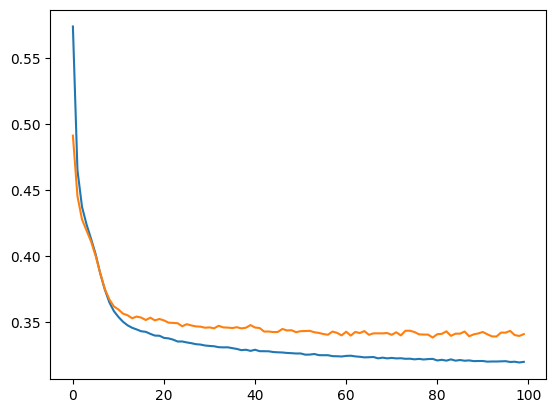

In [95]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

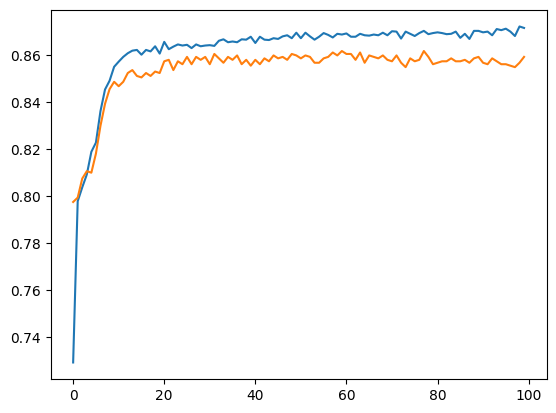

In [96]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])